# 02 — Exploratory Data Analysis

## Objective

This notebook explores the Superstore dataset to identify
sales trends, profitability drivers, customer patterns,
regional performance, and operational insights.

The analysis is driven by business questions rather than
visualization alone.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = "../data/raw/Dataset- Superstore (2015-2018).csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016/11/08,2016/11/11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016/11/08,2016/11/11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016/06/12,2016/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015/10/11,2015/10/18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015/10/11,2015/10/18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [5]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

## 1. Business Overview

In [6]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Unique Orders: 5009
Unique Customers: 793
Unique Products: 1862


In [7]:
profit_margin = df["Profit"].sum() / df["Sales"].sum()

print("Overall Profit Margin:", round(profit_margin * 100, 2), "%")

Overall Profit Margin: 12.47 %


In [8]:
average_order_value = df.groupby("Order ID")["Sales"].sum().mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 458.61


## 2. Sales and Profit by Category

In [9]:
category_performance = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


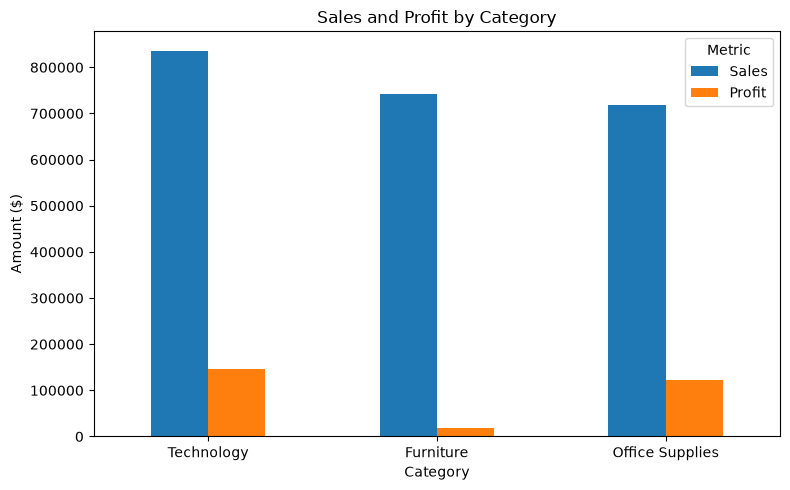

In [10]:
category_performance.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Key Insight

Technology generates the highest sales and profit among the three categories.
Furniture generates sales comparable to Technology but produces substantially
lower profit, indicating a potential profitability issue that requires further
investigation at the sub-category and discount levels.

## 3. Profitability by Sub-Category

In [11]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

subcategory_profit

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

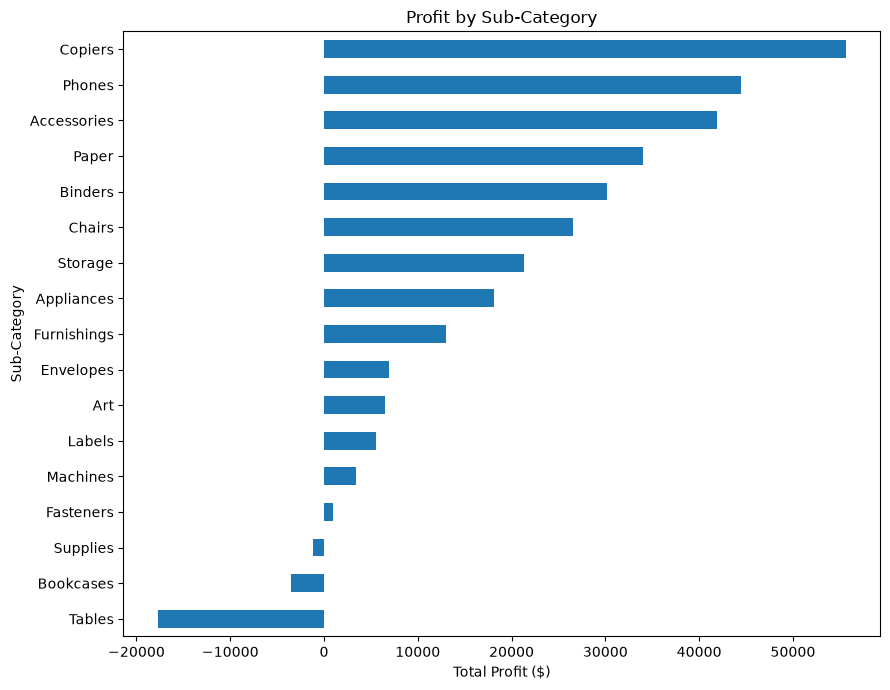

In [12]:
subcategory_profit.plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

### Key Insight

Profitability varies substantially across sub-categories.
Copiers, Phones, and Accessories are the strongest profit contributors,
while Tables is the largest source of loss, followed by Bookcases and
Supplies. This suggests that the drivers of profitability should be
investigated further, particularly the relationship between discounting
and profit.

## 4. Discount and Profitability

In [13]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .agg(["sum", "mean", "count"])
    .sort_index()
)

discount_profit

,sum,mean,count
Discount,,,
0.00,320987.6032,66.900292,4798
0.10,9029.1770,96.055074,94
0.15,1418.9915,27.288298,52
0.20,90337.3060,24.702572,3657
0.30,-10369.2774,-45.679636,227
0.32,-2391.1377,-88.560656,27
0.40,-23057.0504,-111.927429,206
0.45,-2493.1111,-226.646464,11
0.50,-20506.4281,-310.703456,66


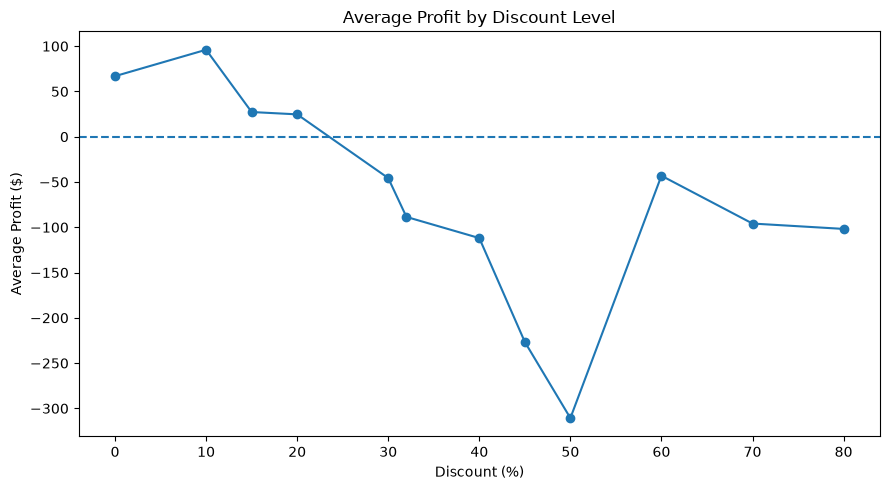

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    discount_profit.index * 100,
    discount_profit["mean"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit ($)")
plt.tight_layout()
plt.show()

### Key Insight

Average profit remains positive at discount levels up to 20% but becomes
negative at 30% and above. Higher discount levels are generally associated
with substantially lower average profitability, with the largest average
loss occurring at a 50% discount. This suggests that aggressive discounting
may be an important contributor to profitability problems and should be
examined alongside product and sub-category performance.

## 5. Discount Patterns by Sub-Category

In [15]:
subcategory_discount = (
    df.groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

subcategory_discount

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64

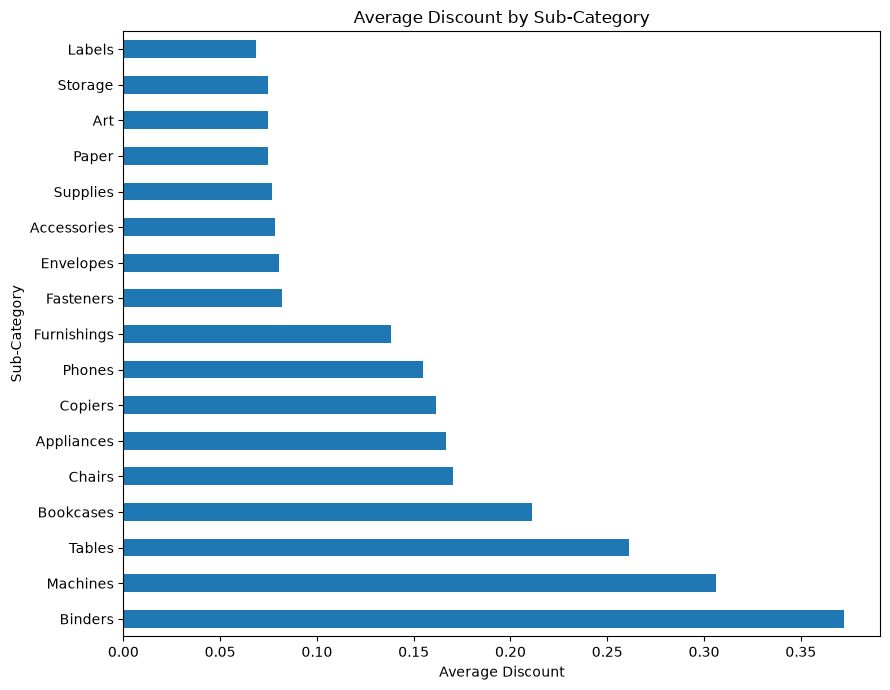

In [16]:
subcategory_discount.plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Average Discount by Sub-Category")
plt.xlabel("Average Discount")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

### Key Insight

Discount levels vary considerably across sub-categories, but high discounting
does not consistently result in losses. Tables and Bookcases combine
relatively high average discounts with negative profitability, while Binders
and Machines maintain positive profitability despite higher average discounts.
This indicates that discount is an important factor to investigate, but it
does not fully explain sub-category profitability on its own.

## 6. Sales, Profit and Profit Margin by Sub-Category

In [17]:
subcategory_performance = (
    df.groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

subcategory_performance["Profit Margin"] = (
    subcategory_performance["Profit"]
    / subcategory_performance["Sales"]
)

subcategory_performance.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Sub-Category,,,
Labels,12486.3120,5546.2540,0.444187
Paper,78479.2060,34053.5693,0.433918
Envelopes,16476.4020,6964.1767,0.422676
Copiers,149528.0300,55617.8249,0.371956
Fasteners,3024.2800,949.5182,0.313965
Accessories,167380.3180,41936.6357,0.250547
Art,27118.7920,6527.7870,0.240711
Appliances,107532.1610,18138.0054,0.168675
Binders,203412.7330,30221.7633,0.148574


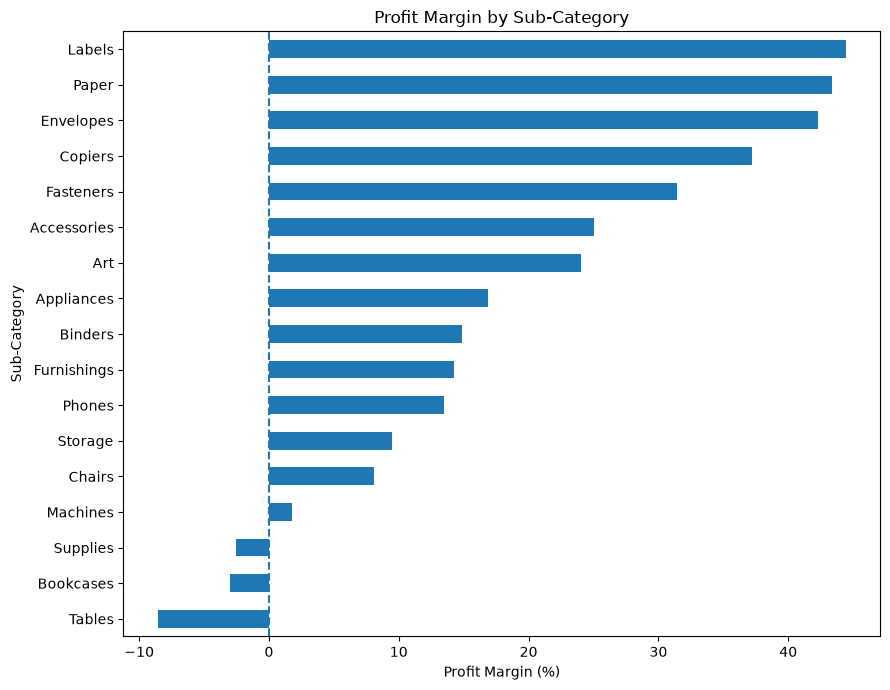

In [18]:
subcategory_performance["Profit Margin (%)"] = (
    subcategory_performance["Profit Margin"] * 100
)

subcategory_performance["Profit Margin (%)"].sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Profit Margin by Sub-Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

### Key Insight

Profit margins vary substantially across sub-categories. Labels, Paper, and
Copiers have the strongest margins, while Tables, Bookcases, and Supplies
have negative margins. Tables are particularly concerning because they combine
the largest absolute loss with a negative profit margin, making them a key
area for further investigation.

## 7. Regional Sales and Profitability

In [19]:
region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

region_performance

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [20]:
region_performance["Profit Margin"] = (
    region_performance["Profit"]
    / region_performance["Sales"]
)

region_performance.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
Central,501239.8908,39706.3625,0.079216


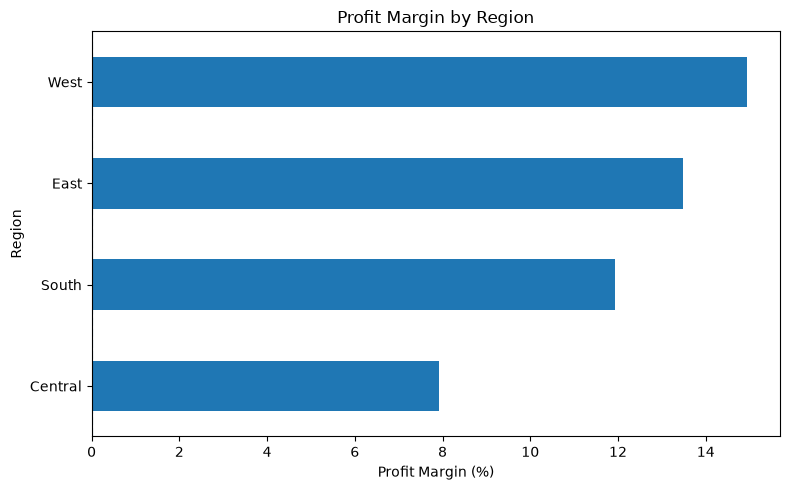

In [21]:
(region_performance["Profit Margin"] * 100).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Profit Margin by Region")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

### Key Insight

The West region has the strongest profit margin at approximately 14.95%,
followed by East at 13.48% and South at 11.93%. Central has the lowest
profit margin at approximately 7.92%, despite generating substantial sales.
This suggests that Central has a profitability gap that may require further
investigation.

## 8. Sales and Profit Trends Over Time

In [22]:
yearly_performance = (
    df.groupby("Year")[["Sales", "Profit"]]
    .sum()
)

yearly_performance

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


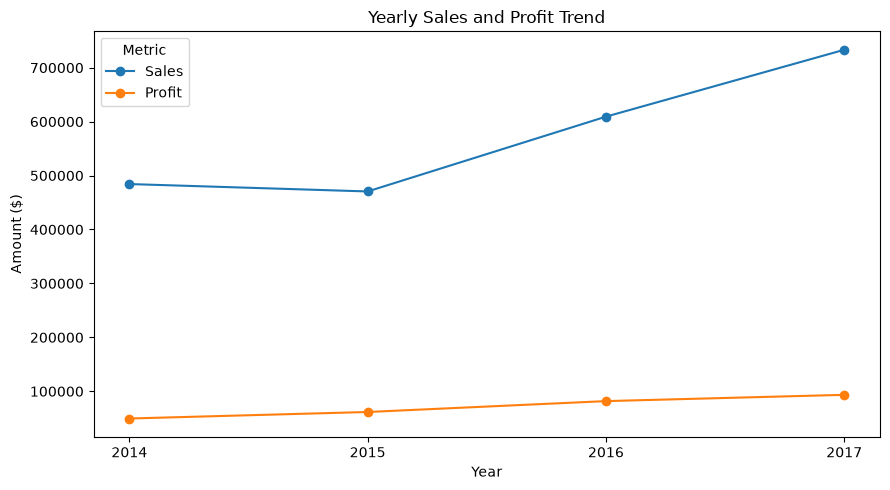

In [23]:
yearly_performance.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.xticks(yearly_performance.index)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [24]:
yearly_growth = yearly_performance.pct_change() * 100

yearly_growth

,Sales,Profit
Year,,
2014,NaN,NaN
2015,-2.832227,24.371540
2016,29.471521,32.744284
2017,20.355962,14.235675


### Key Insight

Year-over-year performance shows that sales and profit do not always grow at
the same rate. In 2015, sales declined by 2.83% while profit increased by
24.37%, indicating improved profitability despite lower revenue. Sales and
profit both grew strongly in 2016. In 2017, sales grew by 20.36% while profit
grew by 14.24%, suggesting that profitability did not keep pace with revenue
growth.

## 9. Monthly Sales Trend

In [25]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

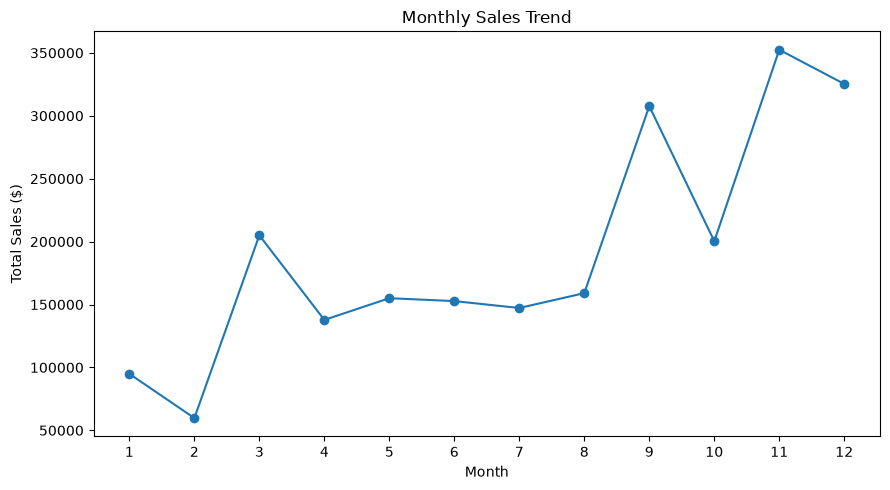

In [26]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Key Insight

Sales show a strong seasonal pattern across the year. February has the
lowest sales, while sales increase substantially from September onward.
November is the strongest month, followed by December and September.
This concentration of sales toward the final months of the year suggests
that seasonal demand should be considered when planning inventory,
marketing, and sales activities.

## 10. Monthly Profit Trend

In [27]:
monthly_profit = (
    df.groupby("Month")["Profit"]
    .sum()
)

monthly_profit

Month
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64

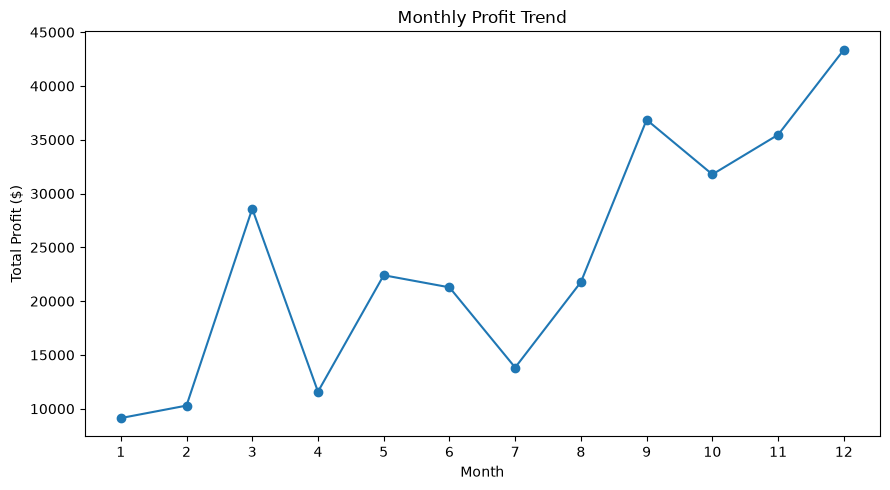

In [28]:
monthly_profit.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit ($)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Key Insight

Monthly profit follows a broadly similar seasonal pattern to sales.
Profit increases substantially from September onward, with December
recording the highest monthly profit at approximately $43.4K. Although
monthly sales and profit both show strong year-end performance, some
months such as July show weaker profitability, indicating that seasonal
sales volume does not always translate into uniform monthly profit.

## 11. Customer Segment Performance

In [29]:
segment_performance = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

segment_performance

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [30]:
segment_performance["Profit Margin"] = (
    segment_performance["Profit"]
    / segment_performance["Sales"]
)

segment_performance.sort_values("Profit Margin", ascending=False)

,Sales,Profit,Profit Margin
Segment,,,
Home Office,4.296531e+05,60298.6785,0.140343
Corporate,7.061464e+05,91979.1340,0.130255
Consumer,1.161401e+06,134119.2092,0.115481


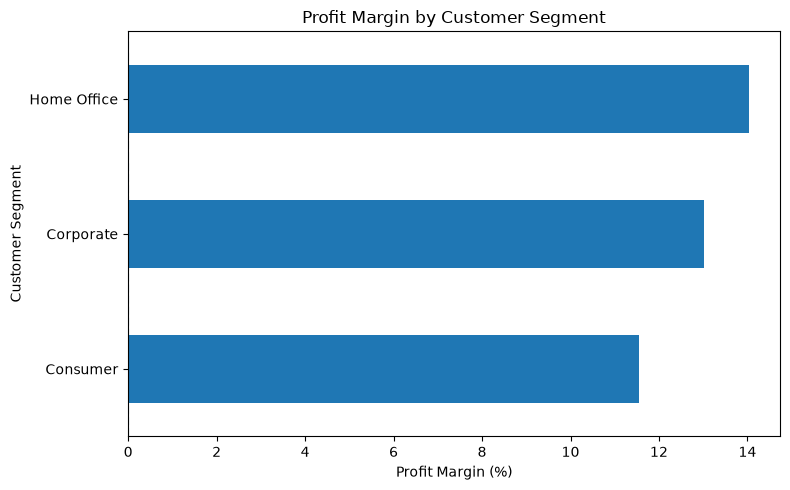

In [31]:
(segment_performance["Profit Margin"] * 100).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Profit Margin by Customer Segment")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Customer Segment")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

### Key Insight

Consumer is the largest customer segment by both sales and total profit,
but it has the lowest profit margin at approximately 11.55%. Home Office
has the highest profit margin at approximately 14.03%, followed by
Corporate at 13.03%. This indicates that the largest customer segment is
not necessarily the most efficient in terms of profitability.

## 12. Customer-Level Performance

In [32]:
customer_performance = (
    df.groupby(["Customer ID", "Customer Name"])[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

customer_performance.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.050,-1980.7393
TC-20980,Tamara Chand,19052.218,8981.3239
RB-19360,Raymond Buch,15117.339,6976.0959
TA-21385,Tom Ashbrook,14595.620,4703.7883
AB-10105,Adrian Barton,14473.571,5444.8055
KL-16645,Ken Lonsdale,14175.229,806.8550
SC-20095,Sanjit Chand,14142.334,5757.4119
HL-15040,Hunter Lopez,12873.298,5622.4292
SE-20110,Sanjit Engle,12209.438,2650.6769


In [33]:
loss_making_customers = customer_performance[
    customer_performance["Profit"] < 0
]

print("Loss-making customers:", len(loss_making_customers))
print(
    "Percentage of customers:",
    round(
        len(loss_making_customers)/ len(customer_performance) * 100,2
    ),
    "%"
)

Loss-making customers: 155
Percentage of customers: 19.55 %


In [34]:
customer_losses = (
    customer_performance[customer_performance["Profit"] < 0]
    .sort_values("Profit")
)

customer_losses.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
CS-12505,Cindy Stewart,5690.055,-6626.3895
GT-14635,Grant Thornton,9351.212,-4108.6589
LF-17185,Luke Foster,3930.509,-3583.9770
SR-20425,Sharelle Roach,3233.481,-3333.9144
HG-14965,Henry Goldwyn,3247.642,-2797.9635
NC-18415,Nathan Cano,2218.990,-2204.8072
SB-20290,Sean Braxton,8057.891,-2082.7451
SM-20320,Sean Miller,25043.050,-1980.7393
CP-12340,Christine Phan,5888.275,-1850.3029


In [35]:
high_value_losses = (
    customer_performance[
        customer_performance["Profit"] < 0
    ]
    .sort_values("Sales", ascending=False)
)

high_value_losses.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.050,-1980.7393
BM-11140,Becky Martin,11789.630,-1659.9581
GT-14635,Grant Thornton,9351.212,-4108.6589
PF-19120,Peter Fuller,9062.864,-614.2943
NF-18385,Natalie Fritzler,8322.826,-1695.9714
SB-20290,Sean Braxton,8057.891,-2082.7451
ZC-21910,Zuschuss Carroll,8025.707,-1032.1490
JH-15985,Joseph Holt,7954.998,-644.6982
JA-15970,Joseph Airdo,6491.026,-819.4217


### Key Insight

Customer-level analysis shows that some relatively high-revenue customers
are still unprofitable. Sean Miller, for example, generated approximately
$25.0K in sales but incurred a loss of approximately $2.0K. This indicates
that revenue contribution alone is not sufficient to evaluate customer
value and that loss-making high-value customers may require further
investigation into factors such as discounts and product mix.

## 13. Shipping Performance

In [36]:
shipping_performance = (
    df.groupby("Ship Mode")["Shipping Days"]
    .agg(["mean", "median", "min", "max", "count"])
    .sort_values("mean")
)

shipping_performance

,mean,median,min,max,count
Ship Mode,,,,,
Same Day,0.044199,0.0,0,1,543
First Class,2.182705,2.0,1,4,1538
Second Class,3.238046,3.0,1,5,1945
Standard Class,5.006535,5.0,3,7,5968


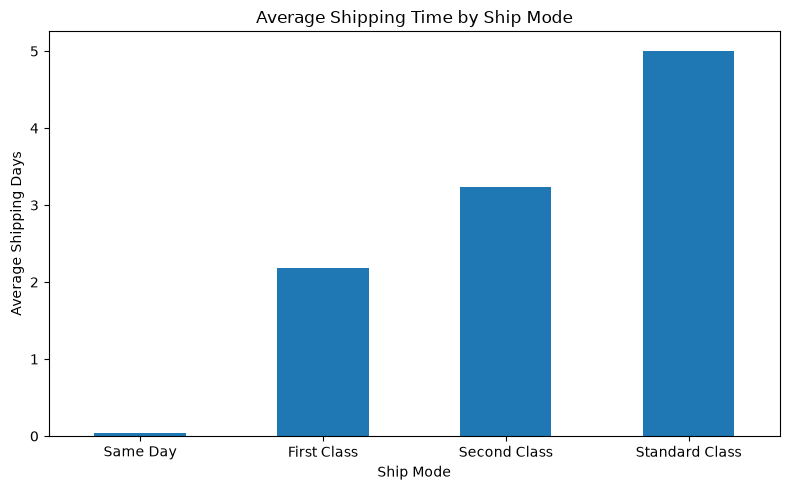

In [37]:
shipping_performance["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Shipping Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Insight

Shipping mode is strongly associated with delivery time. Same Day shipments
have an average delivery time of approximately 0.04 days, followed by First
Class at 2.18 days, Second Class at 3.24 days, and Standard Class at 5.01
days. This confirms a clear difference in fulfillment speed across shipping
modes.

## 14. Category and Regional Performance

In [38]:
category_region_profit = (
    df.groupby(["Region", "Category"])["Profit"]
    .sum()
    .unstack()
)

category_region_profit

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3046.1658,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496


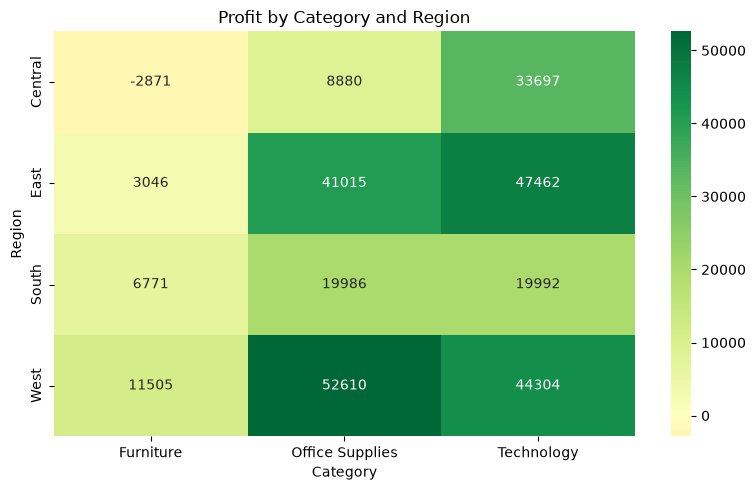

In [39]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    category_region_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Profit by Category and Region")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Key Insight

Profitability varies substantially across region-category combinations.
Central Furniture is the only combination with negative total profit,
at approximately -$2.9K, while Central Technology and Office Supplies
remain profitable. West Office Supplies generates the highest profit
among the combinations at approximately $52.6K. This indicates that
regional performance should be evaluated together with product category
rather than in isolation.

# EDA Summary

The exploratory analysis identified several important business patterns:

- The dataset contains approximately $2.30M in sales and $286.4K in total
  profit, resulting in an overall profit margin of approximately 12.47%.
- Technology generates the highest sales and profit among the three major
  categories, while Furniture has substantially lower profitability.
- Tables, Bookcases, and Supplies have negative total profitability, with
  Tables showing the largest loss.
- Higher discounts are associated with weaker profitability in several
  discount levels, although the relationship is not uniform across all
  sub-categories.
- The West region has the highest sales, profit, and profit margin, while
  Central has the lowest regional profit margin.
- Central Furniture is the only negative region-category combination in the
  analysis.
- Sales and profit generally increased over the years, although their growth
  rates did not always move together.
- Sales and profit show strong seasonal patterns, with particularly strong
  performance toward the end of the year.
- Consumer is the largest customer segment by sales and total profit, while
  Home Office has the highest profit margin.
- Approximately 19.55% of customers are loss-making, and some relatively
  high-revenue customers also generate negative profit.
- Shipping modes show clear differences in average delivery time, ranging
  from Same Day to Standard Class.

These findings provide the business context for the next stage of the
project: developing a machine learning component that can support
data-driven decision-making.